# Import Necessary Libraries

In [1]:
# !pip install -U pip

# !pip install -U tensorflow
# !pip install -U keras
# !pip install -U tensorflow-hub
# !pip install -U tensorflow-text

In [2]:
# Check for GPU
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-58321c32-490b-c4b0-d327-bb99781b66b4)


helper function

In [3]:
# Download helper functions script
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2026-06-02 02:56:38--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.2’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-02 02:56:38 (47.4 MB/s) - ‘helper_functions.py.2’ saved [10246/10246]



In [4]:
# Import series of helper functions for the notebook
from helper_functions import unzip_data, create_tensorboard_callback, plot_loss_curves, compare_historys

# Download Dataset

In [5]:
# Download data (same as from Kaggle)
!wget "https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip"

# Unzip data
unzip_data("nlp_getting_started.zip")

--2026-06-02 02:56:45--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.117.207, 142.250.99.207, 173.194.43.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.117.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip.2’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.008s  

2026-06-02 02:56:45 (68.6 MB/s) - ‘nlp_getting_started.zip.2’ saved [607343/607343]



In [6]:
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [7]:
# Shuffle training data
train_df_shuffled = train_df.sample(frac=1, random_state=42)
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [8]:
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


Test data doesn't have target data.

In [9]:
train_df_shuffled.target.value_counts()

,count
target,
0,4342
1,3271


Since we have two target values, we're dealing with a **binary classification** problem.

It's fairly balanced too, about 60% negative class (`target = 0`) and 40% positive class (`target = 1`).

Where,

* `1` = a real disaster Tweet
* `0` = not a real disaster Tweet

And what about the total number of samples we have?

In [10]:
# how many samples total?

print(f"Total training smaples: {len(train_df)}")
print(f"Total test samples: {len(test_df)}")

print(f"Total samples: {len(train_df) + len(test_df)}")

Total training smaples: 7613
Total test samples: 3263
Total samples: 10876


### Visualize data

In [11]:
# Let's visualize some random training examples

import random
random_index = random.randint(0, len(train_df)-5)

for row in train_df_shuffled[["text", "target"]][random_index:random_index+5].itertuples():
  _, text, target = row
  print(f"Target: {target}", "(real disaster)" if target > 0 else "(not real disaster)")
  print(f"Text:\n{text}\n")
  print("---\n")

Target: 0 (not real disaster)
Text:
Spent too many hours sinking into the wonderfully created worlds of Mafia and Mafia II in my life. Excited for another installment.

---

Target: 0 (not real disaster)
Text:
ng2x5 mhtw4fnet

Watch Michael Jordan absolutely destroy this meme-baiting camper - FOXSportscom

---

Target: 1 (real disaster)
Text:
VIDEO: 'We're picking up bodies from water': Rescuers are searching for hundreds of migrants in the Mediterran... http://t.co/ZFWMjh6SLh

---

Target: 0 (not real disaster)
Text:
@ABCNews24 @PeterDutton_MP 
He also told you....No-one has drowned in the last 2 years &amp; 1200 had under Labor. But let's not mention that..

---

Target: 0 (not real disaster)
Text:
@KJForDays I'm seeing them and Issues at aftershock ??

---



### Data Splitting

In [12]:
from sklearn.model_selection import train_test_split

train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_df_shuffled['text'].to_numpy(),
                                                                            train_df_shuffled['target'].to_numpy(),
                                                                            test_size=0.1,
                                                                            random_state=42)

In [13]:
len(train_sentences), len(val_sentences)

(6851, 762)

In [14]:
len(train_labels), len(val_labels)

(6851, 762)

In [15]:
train_sentences[:10], train_labels[:10]

(array(['@mogacola @zamtriossu i screamed after hitting tweet',
        'Imagine getting flattened by Kurt Zouma',
        '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
        "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
        'Somehow find you and I collide http://t.co/Ee8RpOahPk',
        '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
        'destroy the free fandom honestly',
        'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
        '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
        'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
       dtype=object),
 array([0,

# Data Preprocessing

## Converting text into numbers

Our labels are in numerical form (`0` and `1`) but our Tweets are in string form.


In NLP, there are two main concepts for turning text into numbers:
* **Tokenization** - A straight mapping from word or character or sub-word to a numerical value.

There are three main levels of tokenization:

  1. Using **word-level tokenization** with the sentence "I love TensorFlow" might result in "I" being `0`, "love" being `1` and "TensorFlow" being `2`. In this case, every word in a sequence considered a single **token**.

  2. **Character-level tokenization**, such as converting the letters A-Z to values `1-26`. In this case, every character in a sequence considered a single **token**.

  3. **Sub-word tokenization** is in between word-level and character-level tokenization. It involves breaking invidual words into smaller parts and then converting those smaller parts into numbers. For example, "my favourite food is pineapple pizza" might become "my, fav, avour, rite, fo, oo, od, is, pin, ine, app, le, piz, za". After doing this, these sub-words would then be mapped to a numerical value. In this case, every word could be considered multiple **tokens**.

---

* **Embeddings** - An embedding is a representation of natural language which can be learned. Representation comes in the form of a **feature vector**. For example, the word "dance" could be represented by the 5-dimensional vector `[-0.8547, 0.4559, -0.3332, 0.9877, 0.1112]`. It's important to note here, the size of the feature vector is tuneable. There are two ways to use embeddings:
  1. **Create your own embedding** - Once your text has been turned into numbers (required for an embedding), you can put them through an embedding layer (such as [`tf.keras.layers.Embedding`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding)) and an embedding representation will be learned during model training.
  2. **Reuse a pre-learned embedding** - Many pre-trained embeddings exist online. These pre-trained embeddings have often been learned on large corpuses of text (such as all of Wikipedia) and thus have a good underlying representation of natural language. You can use a pre-trained embedding to initialize your model and fine-tune it to your own specific task.

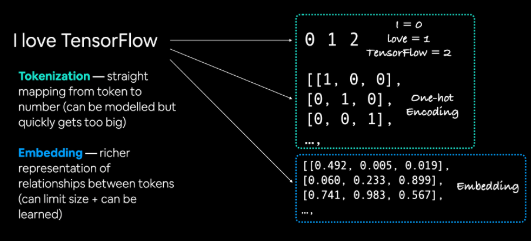

* **Tokenization** (straight mapping from word to number) and

* **Embedding** (richer representation of relationships between tokens).*

ဆိုတော့ Tokenization ကို ဘယ် level သုံးမလဲ? ပြီးတော့ embedding က ရော ဘယ်တစ်ခုသုံးမလဲ?

It depends ပေါ့ဗျာ။ Character-level tokenization/embeddings ကော word-level tokenization/embeddings ကော စမ်းကြည့်ပြီး ဘယ်တစ်ခုက performance အကောင်းဆုံးလဲဆိုတာ ကြည့်ရမှာပါ။

- အဲဒါတွေကို stack လုပ်ပြီး စမ်းကြည့်ရင်တောင် ရပါသေးတယ် (ဥပမာ- embedding layers ရဲ့ output တွေကို tf.keras.layers.concatenate သုံးပြီး ပေါင်းလိုက်တာမျိုးပေါ့)။

- တကယ်လို့ pre-trained word embeddings တွေကို ရှာနေတာဆိုရင်တော့ Word2vec embeddings တို့၊ GloVe embeddings တို့အပြင် TensorFlow Hub မှာ ရနိုင်တဲ့ options အများစုက စတင်ဖို့ အကောင်းဆုံးနေရာတွေပါပဲ။

> 🔑 Note: pre-trained computer vision model တွေကို ရှာသလိုမျိုးပဲ၊ ကိုယ့်ပြဿနာအတွက် သုံးဖို့ pre-trained word embeddings တွေကို ရှာလို့ရပါတယ်။ "use pre-trained word embeddings in TensorFlow" ဆိုပြီး ရှာကြည့်လိုက်ပါ။

---

## Tokenization

Enough talking about tokenization and embeddings, let's create some.

We'll practice tokenzation (mapping our words to numbers) first.

To tokenize our words, we'll use the helpful preprocessing layer [`tf.keras.layers.experimental.preprocessing.TextVectorization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/TextVectorization).

The `TextVectorization` layer takes the following parameters:
* `max_tokens` - The maximum number of words in your vocabulary (e.g. 20000 or the number of unique words in your text), includes a value for OOV (out of vocabulary) tokens.
* `standardize` - Method for standardizing text. Default is `"lower_and_strip_punctuation"` which lowers text and removes all punctuation marks.
* `split` - How to split text, default is `"whitespace"` which splits on spaces.
* `ngrams` - How many words to contain per token split, for example, `ngrams=2` splits tokens into continuous sequences of 2.
* `output_mode` -  How to output tokens, can be `"int"` (integer mapping), `"binary"` (one-hot encoding), `"count"` or `"tf-idf"`. See documentation for more.
* `output_sequence_length` - Length of tokenized sequence to output. For example, if `output_sequence_length=150`, all tokenized sequences will be 150 tokens long.
* `pad_to_max_tokens` - Defaults to `False`, if `True`, the output feature axis will be padded to `max_tokens` even if the number of unique tokens in the vocabulary is less than `max_tokens`. Only valid in certain modes, see docs for more.

### Text Vectorization

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization


# Default TextVectorization parameters
text_vectorizer = TextVectorization(max_tokens=None,
                                    standardize="lower_and_strip_punctuation",
                                    split="whitespace",
                                    ngrams=None,
                                    output_mode="int",
                                    output_sequence_length=None)

text_vectorizer

<TextVectorization name=text_vectorization, built=False>

We've initialized a `TextVectorization` object with the default settings but **let's customize it a little bit for our own use case.**

In particular, let's set values for `max_tokens` and `output_sequence_length`.

For `max_tokens` (the number of words in the vocabulary), multiples of 10,000 (`10,000`, `20,000`, `30,000`) or the exact number of unique words in your text (e.g. `32,179`) are common values.

For our use case, we'll use `10,000`.

And for the `output_sequence_length` we'll use the **average number of tokens per Tweet in the training set**. But first, we'll need to find it.

In [17]:
# Find average number of tokens (words) in training Tweets
round(sum([len(i.split()) for i in train_sentences])/len(train_sentences))

15

အခု နောက်ထပ် text vectorization object တစ်ခုထပ်ဆောက်မယ်။


ဒီတစ်ခုကြတော့ ငါတို့ရဲ့ custom parameters နဲ့ Create လုပ်မယ်။

#### Create Vectorizer

In [18]:
# Setup text vectorization with custom variables
max_vocab_length = 10000 # max number of words to have in our vocabulary
max_length = 15 # max length our sequences will be (e.g. how many words from a Tweet does our model see?)

text_vectorizer = TextVectorization(max_tokens=max_vocab_length,
                                    output_mode="int",
                                    output_sequence_length=max_length)

#### Train Vectorizer

In [19]:
# fit text vectorizer to training text
text_vectorizer.adapt(train_sentences)

#### Test Vectorizer with customed text

In [20]:
# try vectorizer on customed text

sample_sentence = "There's a white cat in my street!"
text_vectorizer([sample_sentence])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[ 264,    3,  381, 1427,    4,   13,  698,    0,    0,    0,    0,
           0,    0,    0,    0]])>

Output က ဘာကို ပြမလဲဆိုတော့:

စာကြောင်း နှစ်ကြောင်းလုံးအတွက် Shape (2, 15) ရှိတဲ့ tensor တစ်ခု ထွက်လာပါလိမ့်မယ်။

စာကြောင်းတွေက စကားလုံး ၁၅ လုံးထက် နည်းနေတဲ့အတွက် ကျန်တဲ့နေရာတွေကို 0 တွေနဲ့ automatic Padding လုပ်ပေးသွားတာကို တွေ့ရပါလိမ့်မယ်ဗျာ။

In [21]:
# On few random sentence from training dataset

# Choose a random sentence from the training dataset and tokenize it
random_sentence = random.choice(train_sentences)
print(f"Original text:\n{random_sentence}\
      \n\nVectorized version:")
text_vectorizer([random_sentence])

Original text:
Sirens everywhere!      

Vectorized version:


<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[ 568, 1528,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0]])>

Now, we can check the unique tokens in our vocabulary with `get_vocabulary()` method.

In [22]:
words_in_vocab = text_vectorizer.get_vocabulary()

# most common tokens
top_5_words = words_in_vocab[:5]

# less common tokens
bottom_5_words = words_in_vocab[-5:]

print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"Most common words: {top_5_words}")
print(f"Least common words: {bottom_5_words}")

Number of words in vocab: 10000
Most common words: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('in')]
Least common words: [np.str_('pages'), np.str_('paeds'), np.str_('pads'), np.str_('padres'), np.str_('paddytomlinson1')]


## Embedding

စကားလုံးတွေကို ကိန်းဂဏန်း integer indices တွေအဖြစ် ပြောင်းပြီးပြီဆိုတော့ ပိုပြီးစွမ်းဆောင်ရည်မြင့်တဲ့ Embedding အဖြစ် ပြောင်းလဲဖို့ အဆင်သင့်ဖြစ်ပြီ။

Tokenization (Integer mapping) က စကားလုံးတစ်လုံးချင်းစီကို static ဖြစ်တဲ့ (မပြောင်းလဲတဲ့) နံပါတ်တစ်ခုစီ ပေးလိုက်ရုံပဲ ဖြစ်ပေမဲ့ (1 = I, 2 = love)၊ Embedding Layer ကတော့ အဲဒီနံပါတ်တွေကို သိပ်သည်းတဲ့ vector (dense vector) တွေအဖြစ် ပြောင်းလဲပေးပါတယ်။ အဓိက ထူးခြားချက်က မော်ဒယ်ကို train နေစဉ်အတွင်းမှာ အဓိပ္ပာယ်တူတဲ့ စကားလုံးတွေရဲ့ vector တွေက space ထဲမှာ တစ်ခုနဲ့တစ်ခု နီးကပ်လာအောင် သူတို့ရဲ့ တန်ဖိုးတွေကို မော်ဒယ်က စဉ်ဆက်မပြတ် သင်ယူ (learn) သွားမှာ ဖြစ်ပါတယ်။

ကဲ... အပေါ်မှာ ပြောခဲ့တဲ့ parameter တွေကို သုံးပြီး ၐtf.keras.layers.Embedding layerၐ တစ်ခုကို တည်ဆောက်ကြည့်ရအောင်။

The main parameters we're concerned about here are:
* `input_dim` - The size of the vocabulary (e.g. `len(text_vectorizer.get_vocabulary()`).
* `output_dim` - The size of the output embedding vector, for example, a value of `100` outputs a  feature vector of size 100 for each word.
* `embeddings_initializer` - How to initialize the embeddings matrix, default is `"uniform"` which randomly initalizes embedding matrix with uniform distribution. This can be changed for using pre-learned embeddings.
* `input_length` - Length of sequences being passed to embedding layer.

In [23]:
tf.random.set_seed(42)
from tensorflow.keras import layers

embedding = layers.Embedding(input_dim=max_vocab_length, # sequence length
                             output_dim=128, # size of embedding vector
                             embeddings_initializer="uniform",
                             input_length=max_length,
                             name='embedding_1')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


15 = Sequence length (စာကြောင်းထဲမှာ ပါဝင်တဲ့ tokens/words အရေအတွက်)

128 = Embedding dimension (စကားလုံး တစ်လုံးချင်းစီ အတွက် ထွက်လာတဲ့ numeric features အရေအတွက်)

In [24]:
# test embedding on random sentence

random_sentence = random.choice(train_sentences)
print(f"Original text:\n{random_sentence}\n")

print("Embedded version:")

# Embed the sentence
sampled_embed = embedding(text_vectorizer([random_sentence]))
sampled_embed

Original text:
destroy the free fandom honestly

Embedded version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[ 0.01011652,  0.02958888, -0.02834523, ...,  0.03768079,
         -0.02609594, -0.03739833],
        [-0.01225084,  0.00092746, -0.02311827, ..., -0.02510853,
          0.02565715, -0.00070343],
        [-0.01280973, -0.04954025,  0.04477611, ..., -0.00603272,
         -0.04929879,  0.03162812],
        ...,
        [ 0.03249368, -0.02959385,  0.01821977, ..., -0.01252828,
          0.03870468,  0.04269519],
        [ 0.03249368, -0.02959385,  0.01821977, ..., -0.01252828,
          0.03870468,  0.04269519],
        [ 0.03249368, -0.02959385,  0.01821977, ..., -0.01252828,
          0.03870468,  0.04269519]]], dtype=float32)>

Each token in the sentence gets turned into a length 128 feature vector as the output size is 128 (size of embedded vector).

In [25]:
# Check out a single token's embedding
# len(sampled_embed[0][0])

print(sampled_embed[0][0])

tf.Tensor(
[ 1.0116518e-02  2.9588882e-02 -2.8345227e-02  8.9555606e-03
 -3.9087176e-02  2.3532782e-02 -4.5321107e-02 -1.6558159e-02
 -6.9356561e-03  1.6943302e-02 -4.1184865e-02  4.6436135e-02
 -1.9814301e-02  2.7645480e-02  6.7481995e-03 -2.1428252e-02
  4.4329766e-02  3.0397024e-02 -8.0321543e-03  2.0763885e-02
 -1.2606382e-04  1.4540564e-02 -3.2747984e-03  2.3726013e-02
  4.0737215e-02 -4.6766512e-03  2.8028339e-04 -1.7128810e-03
 -1.3580181e-02  9.4738379e-03  5.3376332e-03  2.5575224e-02
  2.5290500e-02 -3.5966229e-02 -4.5935027e-03  5.8945306e-03
  3.9428245e-02  4.6432409e-02  4.5042638e-02 -1.7276369e-02
  3.5283234e-02 -5.9471354e-03 -3.8890861e-02 -1.1388160e-02
  1.3865892e-02 -4.2807546e-02  1.8258702e-02 -4.9298324e-02
  3.7014972e-02  2.3472521e-02 -2.3704160e-02  1.8327761e-02
 -1.9838369e-02 -3.1729780e-02  4.4292238e-02  4.9609665e-02
  4.7811221e-02 -2.5944782e-02  3.2009315e-02 -9.8875277e-03
 -2.9309262e-02 -3.3066891e-02  2.4214387e-06  1.1017598e-02
 -4.3616749e-

ဒီဒသမကိန်း (floating-point numbers) တွေက ကျွန်တော်တို့အတွက်တော့ ဘာအဓိပ္ပာယ်မှ မရှိသလို ဖြစ်နေနိုင်ပေမဲ့ ကွန်ပျူတာအတွက်ကတော့ ဒါဟာ စကားလုံးတစ်လုံးချင်းစီရဲ့ စရိုက်လက္ခဏာ (features) တွေပဲ ဖြစ်ပါတယ်။

မော်ဒယ်က Data samples တွေကို တစ်ကြောင်းပြီးတစ်ကြောင်း ကြည့်ပြီး pattern ရှာတဲ့အခါ (Training လုပ်တဲ့အခါ) အဓိပ္ပာယ်ချင်း ဆင်တူတဲ့ စကားလုံးတွေရဲ့ weight တန်ဖိုးတွေကို အနီးစပ်ဆုံး ဖြစ်သွားအောင် ဒီ vector values တွေကို လိုအပ်သလို အမြဲတမ်း update လုပ်ပြီး ပြင်ဆင်သွားမှာ ဖြစ်ပါတယ်။

မော်ဒယ်က စာတွေကို ကိုယ်တိုင်ဖတ်ပြီး "King" (0.95) နဲ့ "Queen" (0.95) ဟာ အဓိပ္ပာယ်ချင်း နီးစပ်ပေမဲ့ ကျား/မ ကွဲပြားတယ်ဆိုတာကို ဒီ vector တန်ဖိုးတွေကတစ်ဆင့် သင်ယူသွားတာ ဖြစ်ပါတယ်။ Apple (0.01) ကျတော့ သူတို့နဲ့ လုံးဝမဆိုင်တဲ့အတွက် vector space ထဲမှာ အဝေးကြီးကို ရောက်သွားမှာပါ။

> 🔑 Note: အခုပြောသွားတဲ့ Tokenization (စာသားကို နံပါတ်ပြောင်းခြင်း) နဲ့ Embeddings (နံပါတ်ကို vector အဓိပ္ပာယ်ဖော်ခြင်း) ဆိုတဲ့ အယူအဆ နှစ်ခုဟာ Natural Language Processing (NLP) တစ်ခုလုံးရဲ့ အခြေခံအကျဆုံး ကျောက်မြစ်တွေ ဖြစ်ပါတယ်။

ဒီအပိုင်းကို သေချာနားလည်ထားမှ ရှေ့ခရီးဆက်ရတာ ပိုလွယ်ကူမှာမို့လို့ လိုအပ်ရင် ကိုယ်ပိုင် text data အတိုလေးတွေနဲ့ Tokenizer ကော Embedding ပါ ပြောင်းလဲပုံတွေကို အထပ်ထပ် အခါခါ စမ်းသပ် (experiment) ကြည့်ဖို့ တိုက်တွန်းချင်ပါတယ်ဗျာ။

---

# Modelling

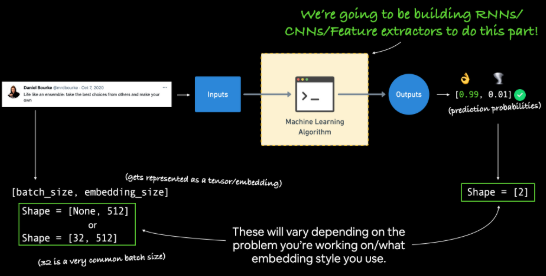

*Once you've got your inputs and outputs prepared, it's a matter of figuring out which machine learning model to build in between them to bridge the gap.*

Now that we've got a way to turn our text data into numbers, we can start to build machine learning models to model it.

To get plenty of practice, we're going to build a series of different models, each as its own experiment. We'll then compare the results of each model and see which one performed best.

More specifically, we'll be building the following:
* **Model 0**: Naive Bayes (baseline)
* **Model 1**: Feed-forward neural network (dense model)
* **Model 2**: LSTM model
* **Model 3**: GRU model
* **Model 4**: Bidirectional-LSTM model
* **Model 5**: 1D Convolutional Neural Network


* **Model 6**: TensorFlow Hub Pretrained Feature Extractor
* **Model 7**: Same as model 6 with 10% of training data


---

## Model 0 (+ Baseline)

Model 0 is the simplest to acquire a baseline which we'll expect each other of the other deeper models to beat.

Each experiment will go through the following steps:
* Construct the model
* Train the model
* Make predictions with the model
* Track prediction evaluation metrics for later comparison

---

ဒီ Baseline Model ကို တည်ဆောက်ဖို့အတွက် Scikit-Learn Pipeline ကို အသုံးပြု ပါမယ်။ Pipeline ထဲမှာ -

- TF-IDF (Term Frequency – Inverse Document Frequency) ကို အသုံးပြုပြီး စာသား (text) တွေကို ကွန်ပျူတာနားလည်နိုင်တဲ့ ကိန်းဂဏန်း (numerical features) အဖြစ် ပြောင်းလဲမယ်။

- ပြောင်းလဲထားတဲ့ Feature တွေကို Multinomial Naive Bayes Algorithm နဲ့ Training ပြုလုပ်ပြီး Classification Model တစ်ခု တည်ဆောက်မယ်။

[Multinomial Naive Bayes Algorithm]((https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB) ကို ရွေးချယ်ရတဲ့ အကြောင်းရင်းကတော့ Text Classification ပြဿနာတွေ (ဥပမာ - Spam Detection, Sentiment Analysis) အတွက် ရိုးရှင်းပြီး ထိရောက်မှုကောင်းတာကြောင့် ဖြစ်ပါတယ်။ ဒီ Algorithm ကို ရွေးချယ်ရာမှာလည်း Scikit-Learn ရဲ့ [Machine Learning Map](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) ကို ကိုးကားထားပါတယ်။


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [27]:
model_0 = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

model_0.fit(train_sentences, train_labels)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

The benefit of using a shallow model like Multinomial Naive Bayes is that training is very fast.

Now, we will set the baseline score to compare future updated models.

### Baseline Score

In [28]:
baseline_score = model_0.score(val_sentences, val_labels)
print(f"Our baseline model's accuracy: {baseline_score*100:.2f}%")

Our baseline model's accuracy: 79.27%


In [29]:
# Make some predictions
baseline_preds = model_0.predict(val_sentences)
baseline_preds[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

### Creating an evaluation function for our model experiments

We could evaluate these as they are but since we're going to be evaluating several models in the same way going forward, let's create a helper function which takes an array of predictions and ground truth labels and computes the following:
* Accuracy
* Precision
* Recall
* F1-score

> 🔑 **Note:** Since we're dealing with a classification problem, the above metrics are the most appropriate. If we were working with a regression problem, other metrics such as MAE (mean absolute error) would be a better choice.

### Baseline Results

In [30]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):

  # Model accuracy
  model_accuracy = accuracy_score(y_true, y_pred) * 100

  # Other metrics
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

  model_results = {"accuracy": model_accuracy,
                   "precision": model_precision,
                   "recall": model_recall,
                   "f1": model_f1}

  return model_results

In [31]:
# Get baseline results

baseline_results = calculate_results(y_true=val_labels, y_pred=baseline_preds)

baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

---

## Model 1 (+ Simple NN)

In [32]:
# Create model

inputs = layers.Input(shape=(1,), dtype="string")

# Vectorizer
x = text_vectorizer(inputs)

# Embedding
x = embedding(x)

# AvgPooling 1D
x = layers.GlobalAveragePooling1D()(x)

# Output (sigmoid - binary classification)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_1 = tf.keras.Model(inputs, outputs, name='model_1_dense')

ဘာကြောင့် Pooling လိုတာလဲ?

Pooling Layer က
```
Many Token Representations
        ↓
Single Tweet Representation
```

အဖြစ် ပြောင်းပေးပါတယ်။ ဒါကြောင့်

```
Tweet တစ်ခု
      ↓
Embedding
      ↓
Pooling
      ↓
Single Feature Vector
      ↓
Prediction
```

---

Embedding Layer ရဲ့ Output Shape ဟာ

```(batch_size, sequence_length, embedding_dim)```

ဥပမာ (32, 15, 128) ဖြစ်ပါတယ်။

- 32 = Batch Size
- 15 = Tweet တစ်ခုစီမှာ Token 15 ခု
- 128 = Embedding Dimension

GlobalAveragePooling1D() က

Token Embeddings အားလုံး ၏ Average ကိုယူပေးတယ်။

```
[[1,2],
 [3,4],
 [5,6]]

   ↓

[(1+3+5)/3,
 (2+4+6)/3]

   ↓

[3,4]
```

ဆိုတော့ shape က `(32, 15, 128)` ကနေ `(32, 128)` သို့လျော့သွားပါမယ်။

---

In [33]:
model_1.compile(optimizer=tf.keras.optimizers.Adam(),
                loss="binary_crossentropy",
                metrics=['accuracy'])

In [34]:
model_1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,129 (4.88 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train the model_1

model_1_history = model_1.fit(train_sentences, train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6961 - loss: 0.6069 - val_accuracy: 0.7612 - val_loss: 0.5347
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8164 - loss: 0.4433 - val_accuracy: 0.7887 - val_loss: 0.4743
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8580 - loss: 0.3508 - val_accuracy: 0.7913 - val_loss: 0.4619
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8888 - loss: 0.2884 - val_accuracy: 0.7887 - val_loss: 0.4679
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9089 - loss: 0.2416 - val_accuracy: 0.7795 - val_loss: 0.4834


In [36]:
# Check the results
model_1.evaluate(val_sentences, val_labels)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7795 - loss: 0.4834


[0.4834034740924835, 0.7795275449752808]

Training က ကောင်းတယ်။ validation မှာနည်းနည်းညံ့တယ်။

ဆိုတော့ overfit ဖြစ်နေတုန်း လို့ယူဆလို့ရတယ်။

In [37]:
embedding.weights

[<Variable path=embedding_1/embeddings, shape=(10000, 128), dtype=float32, value=[[ 0.02873307 -0.0289527   0.02334048 ... -0.01411369  0.02899528
    0.04064344]
  [ 0.02170596 -0.0380119  -0.02734051 ... -0.029977   -0.02105035
   -0.04122535]
  [ 0.00639088 -0.01692649 -0.00553672 ... -0.04146081  0.0469221
   -0.01806349]
  ...
  [ 0.0106393   0.01064225  0.0315744  ... -0.04345297  0.03378893
   -0.01912422]
  [ 0.00400126 -0.0804209   0.03936309 ... -0.01321679  0.01984266
   -0.05289251]
  [ 0.10426854 -0.09299695  0.08783476 ... -0.01719983  0.05383924
   -0.07263588]]>]

In [38]:
embed_weights = model_1.get_layer("embedding_1").get_weights()[0]

print(embed_weights.shape)

(10000, 128)


In [39]:
# Make predictions (these come back in the form of probabilities)
model_1_pred_probs = model_1.predict(val_sentences)
model_1_pred_probs[:10] # only print out the first 10 prediction probabilities

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[0.3293553 ],
       [0.734324  ],
       [0.9975374 ],
       [0.18804353],
       [0.10033337],
       [0.9450906 ],
       [0.891834  ],
       [0.9939301 ],
       [0.9601781 ],
       [0.3943756 ]], dtype=float32)

Threshold 0.5 က ‌model အခြေအနေပေါ်မူတည်ပြီးပြောင်းလို့ရတယ်။

Model_1's metrics

In [40]:
# Turn prediction probabilities into single-dimension tensor of floats
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs)) # squeeze removes single dimensions
model_1_preds[:20]

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1.], dtype=float32)>

In [41]:
# Calculate model_1 metrics
model_1_results = calculate_results(y_true=val_labels,
                                    y_pred=model_1_preds)
model_1_results

{'accuracy': 77.95275590551181,
 'precision': 0.7825962002002497,
 'recall': 0.7795275590551181,
 'f1': 0.7770045099502749}

ဆိုးတော့မဆိုးဘူး baseline model ထက်ပိုကောင်းလာတယ်လား? ကြည့်ရအောင်

#### Create a helper function to compare the baseline results to new model results

In [42]:
def compare_baseline_to_new_results(baseline_results, new_model_results):
  for key, value in baseline_results.items():
    print(f"Baseline {key}: {value:.2f}, New {key}: {new_model_results[key]:.2f}, | Difference: {new_model_results[key] - value:.2f}")

In [43]:
# baseline Vs. model-1

compare_baseline_to_new_results(baseline_results, model_1_results)

Baseline accuracy: 79.27, New accuracy: 77.95, | Difference: -1.31
Baseline precision: 0.81, New precision: 0.78, | Difference: -0.03
Baseline recall: 0.79, New recall: 0.78, | Difference: -0.01
Baseline f1: 0.79, New f1: 0.78, | Difference: -0.01


baseline model က ပိုကောင်းနေတယ် Simple NN ထက်။ ဆိုတော့ အခု RNN (Recurrent NN) နဲ့ စမ်းကြည့်ရမယ်။

---

## RNNs Model

Recurrent Neural Network (RNN) ဆိုတာက sequence data (အဆင့်လိုက်စဉ်ဆက်ရှိတဲ့ data) တွေကို နားလည်ဖို့အတွက် အသုံးပြုတဲ့ Neural Network မျိုး။

အဓိက idea ကတော့—

> "အတိတ် (past information) ကို အသုံးပြုပြီး အနာဂတ် (future prediction) ကို ခန့်မှန့်မယ်"

ပုံမှန် Neural Network တွေက input တစ်ခုချင်းစီကို သီးသန့် (independent) အနေနဲ့ကြည့်ပါတယ်။

ဒါပေမယ့် RNN ကတော့—

```
X(t) → y(t)
        ↑
     memory (previous state)
```

အရင် input တွေကို memory ထဲမှာ မှတ်ထားပြီး နောက် input ကို အဲဒီ context နဲ့အတူ ခန့်မှန်းပါတယ်။

---

**Why important in NLP?**

Text (စာကြောင်း) တွေမှာ word order က အဓိပ္ပါယ်ကို ပြောင်းလဲနိုင်ပါတယ်။

ဥပမာ—
```
Sentence 1

Massive earthquake last week, no?
```

```
Sentence 2

No massive earthquake last week.
```

👉 စကားလုံးတွေက တူပေမယ့် order မတူလို့ meaning မတူ ပါ။

RNN က ဒီ order ကို သိမ်းထားပြီး context ကိုနားလည်နိုင်ပါတယ်။

---

### How RNNs work

RNN က sentence ကို word-by-word ဖတ်ပါတယ်။

```
"I" → "love" → "machine" → "learning"

အချိန်တိုင်းမှာ—

hidden state = previous memory + current word
```

ဆိုပြီး update လုပ်ပါတယ်။




---

### Tasks (Sequence Problem Types)

RNN ကို အောက်ပါ tasks တွေမှာ အသုံးပြုနိုင်ပါတယ်—

```
1. One-to-One
Input → Output
Image → Label (cat/dog)
2. One-to-Many
Image → Sentence

ဥပမာ: Image Captioning
```

```
3. Many-to-One ⭐ (ကျွန်တော်တို့ project)
Tweet → Spam / Not Spam
Sentence → Class label

👉 Text Classification
```

```
4. Many-to-Many
English sentence → Spanish sentence
Audio → Text
```

### RNN Variants

RNN တွေက simple version မကောင်းတဲ့အတွက် အောက်ပါ advanced versions တွေကို သုံးပါတယ်—

🔹 LSTM (Long Short-Term Memory)

- Long-term memory ကိုကောင်းကောင်း handle လုပ်နိုင်တယ်

- Vanishing gradient problem ကို ဖြေရှင်းတယ်

🔹 GRU (Gated Recurrent Unit)

- LSTM ထက် ပိုရိုးရှင်းပြီး fast

- Performance ကလည်းကောင်း

🔹 Bidirectional RNN

- 👉 Forward (left → right)
- 👉 Backward (right → left)

- Context နှစ်ဘက်လုံးကိုကြည့်နိုင်တယ်

ဒါကြောင့် TF-IDF ထက် RNN က—

| TF-IDF       | RNN            |
| ------------ | -------------- |
| Order မသိ    | Order သိ       |
| Bag of words | Sequence-aware |
| Simple       | Powerful       |



---

## Model 2 (+ LSTM)

In [44]:
tf.random.set_seed(42)
model_2_embedding = layers.Embedding(input_dim=max_vocab_length,
                                     output_dim=128,
                                     embeddings_initializer='uniform',
                                     input_length=max_length,
                                     name='embedding_2')

# Create LSTM model
inputs = layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = model_2_embedding(x)
print(x.shape)

x = layers.LSTM(64, return_sequences=False)(x)
print(x.shape)

outputs = layers.Dense(1, activation='sigmoid')(x)
model_2 = tf.keras.Model(inputs, outputs, name="model_2_LSTM")

(None, 15, 128)
(None, 64)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [45]:
model_2.compile(optimizer=tf.keras.optimizers.Adam(),
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [46]:
model_2.summary()

Model: "model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

Looking good! You'll notice a fair few more trainable parameters within our LSTM layer than `model_1`.

If you'd like to know where this number comes from, I recommend going through the above resources as well the following on calculating the number of parameters in an LSTM cell:
* [Stack Overflow answer to calculate the number of parameters in an LSTM cell](https://stackoverflow.com/questions/38080035/how-to-calculate-the-number-of-parameters-of-an-lstm-network) by Marcin Możejko
* [Calculating number of parameters in a LSTM unit and layer](https://medium.com/@priyadarshi.cse/calculating-number-of-parameters-in-a-lstm-unit-layer-7e491978e1e4) by Shridhar Priyadarshi

Now our first RNN model's compiled let's fit it to our training data, validating it on the validation data and tracking its training parameters using our TensorBoard callback.

In [47]:
# fit model
model_2_history = model_2.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7402 - loss: 0.5143 - val_accuracy: 0.7664 - val_loss: 0.4624
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8714 - loss: 0.3162 - val_accuracy: 0.7651 - val_loss: 0.5148
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9203 - loss: 0.2180 - val_accuracy: 0.7533 - val_loss: 0.5926
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9494 - loss: 0.1553 - val_accuracy: 0.7651 - val_loss: 0.5932
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9623 - loss: 0.1224 - val_accuracy: 0.7782 - val_loss: 0.6468


Make predictions on the validation dataset

In [48]:
model_2_pred_probs = model_2.predict(val_sentences)
model_2_pred_probs.shape, model_2_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


((762, 1),
 array([[0.02299523],
        [0.9456802 ],
        [0.9965132 ],
        [0.05031181],
        [0.00789999],
        [0.9958691 ],
        [0.6406978 ],
        [0.9989004 ],
        [0.9974274 ],
        [0.24305807]], dtype=float32))

In [49]:
# round out predictions
# use squeeze (reduce to 1-dimensional array)
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

Beautiful, now let's use our `caculate_results()` function to evaluate our LSTM model and our `compare_baseline_to_new_results()` function to compare it to our baseline model.

Results

In [50]:
model_2_results = calculate_results(y_true=val_labels,
                                    y_pred=model_2_preds)
model_2_results

{'accuracy': 77.82152230971128,
 'precision': 0.7821410753906608,
 'recall': 0.7782152230971129,
 'f1': 0.7753203421645093}

In [51]:
# Compare with baseline

compare_baseline_to_new_results(baseline_results, model_2_results)

Baseline accuracy: 79.27, New accuracy: 77.82, | Difference: -1.44
Baseline precision: 0.81, New precision: 0.78, | Difference: -0.03
Baseline recall: 0.79, New recall: 0.78, | Difference: -0.01
Baseline f1: 0.79, New f1: 0.78, | Difference: -0.01


## Model 3 (+ GRU)



Another popular and effective RNN component is the GRU or gated recurrent unit.

The GRU cell has similar features to an LSTM cell but has less parameters.

> 📖 **Resource:** A full explanation of the GRU cell is beyond the scope of this noteook but I'd suggest the following resources to learn more:
* [Gated Recurrent Unit](https://en.wikipedia.org/wiki/Gated_recurrent_unit) Wikipedia page
* [Understanding GRU networks](https://towardsdatascience.com/understanding-gru-networks-2ef37df6c9be) by Simeon Kostadinov

To use the GRU cell in TensorFlow, we can call the [`tensorflow.keras.layers.GRU()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU) class.

The architecture of the GRU-powered model will follow the same structure we've been using:

```
Input (text) -> Tokenize -> Embedding -> Layers -> Output (label probability)
```

Again, the only difference will be the layer(s) we use between the embedding and the output.

In [52]:
tf.random.set_seed(42)
model_3_embedding = layers.Embedding(input_dim=max_vocab_length,
                                     output_dim=128,
                                     embeddings_initializer='uniform',
                                     input_length=max_length,
                                     name='embedding_3')

# Create GRU model

inputs = layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = model_3_embedding(x)
print(x.shape)

x = layers.GRU(64)(x)
print(x.shape)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_3 = tf.keras.Model(inputs, outputs, name='model_3_GRU')

(None, 15, 128)
(None, 64)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [53]:
model_3.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [54]:
model_3.summary()

Model: "model_3_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# fit model_3

model_3_history = model_3.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7253 - loss: 0.5270 - val_accuracy: 0.7808 - val_loss: 0.4547
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8724 - loss: 0.3131 - val_accuracy: 0.7664 - val_loss: 0.5113
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9183 - loss: 0.2177 - val_accuracy: 0.7546 - val_loss: 0.5728
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9435 - loss: 0.1660 - val_accuracy: 0.7651 - val_loss: 0.5606
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9578 - loss: 0.1380 - val_accuracy: 0.7625 - val_loss: 0.6454


In [56]:
# Predict
model_3_pred_probs = model_3.predict(val_sentences)
model_3_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[0.05720503],
       [0.86289465],
       [0.9940474 ],
       [0.10704924],
       [0.01400496],
       [0.9903861 ],
       [0.39128572],
       [0.99445504],
       [0.9953198 ],
       [0.80245304]], dtype=float32)

In [57]:
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 0., 1., 1., 1.], dtype=float32)>

In [58]:
# Results

model_3_results = calculate_results(y_true=val_labels,
                                    y_pred=model_3_preds)
model_3_results

{'accuracy': 76.24671916010499,
 'precision': 0.7645157014219752,
 'recall': 0.7624671916010499,
 'f1': 0.7599672431611975}

In [59]:
# Compare
compare_baseline_to_new_results(baseline_results, model_3_results)

Baseline accuracy: 79.27, New accuracy: 76.25, | Difference: -3.02
Baseline precision: 0.81, New precision: 0.76, | Difference: -0.05
Baseline recall: 0.79, New recall: 0.76, | Difference: -0.03
Baseline f1: 0.79, New f1: 0.76, | Difference: -0.03


---

## Model 4 (+ Bidirectional RNN model)

Look at us go! We've already built two RNN's with GRU and LSTM cells. Now we're going to look into another kind of RNN, the bidirectional RNN.

A standard RNN will process a sequence from left to right, where as a bidirectional RNN will process the sequence from left to right and then again from right to left.

Intuitively, this can be thought of as if you were reading a sentence for the first time in the normal fashion (left to right) but for some reason it didn't make sense so you traverse back through the words and go back over them again (right to left).

In practice, many sequence models often see and improvement in performance when using bidirectional RNN's.

However, this improvement in performance often comes at the cost of longer training times and increased model parameters (since the model goes left to right and right to left, the number of trainable parameters doubles).

Okay enough talk, let's build a bidirectional RNN.

Once again, TensorFlow helps us out by providing the [`tensorflow.keras.layers.Bidirectional`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional) class. We can use the `Bidirectional` class to wrap our existing RNNs, instantly making them bidirectional.

In [60]:
tf.random.set_seed(42)
model_4_embedding = layers.Embedding(input_dim=max_vocab_length,
                                     output_dim=128,
                                     embeddings_initializer='uniform',
                                     input_length=max_length,
                                     name='embedding_4')

# Build a Bidirecitonal RNN
inputs = layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = model_4_embedding(x)

x = layers.Bidirectional(layers.LSTM(64))(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_4 = tf.keras.Model(inputs, outputs, name='model_4_Bidirectional')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [61]:
model_4.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [62]:
model_4.summary()

Model: "model_4_Bidirectional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

Notice the increased number of trainable parameters in `model_4` (bidirectional LSTM) compared to `model_2` (regular LSTM). This is due to the bidirectionality we added to our RNN.

Time to fit our bidirectional model and track its performance.

In [63]:
model_4_history = model_4.fit(train_sentences, train_labels, epochs=5, validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7453 - loss: 0.5150 - val_accuracy: 0.7822 - val_loss: 0.4638
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8705 - loss: 0.3140 - val_accuracy: 0.7756 - val_loss: 0.5005
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9219 - loss: 0.2110 - val_accuracy: 0.7572 - val_loss: 0.5987
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9562 - loss: 0.1402 - val_accuracy: 0.7533 - val_loss: 0.6797
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9666 - loss: 0.1073 - val_accuracy: 0.7402 - val_loss: 0.7532


In [64]:
# predict
model_4_pred_probs = model_4.predict(val_sentences)
model_4_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


array([[0.30542392],
       [0.98342115],
       [0.99954826],
       [0.04930682],
       [0.00599475],
       [0.9891833 ],
       [0.910303  ],
       [0.99989176],
       [0.9998318 ],
       [0.7776289 ]], dtype=float32)

In [65]:
# round and reduce to 1D
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))
model_4_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [66]:
# Results
model_4_results = calculate_results(y_true=val_labels,
                                    y_pred=model_4_preds)
model_4_results

{'accuracy': 74.01574803149606,
 'precision': 0.7396206156048676,
 'recall': 0.7401574803149606,
 'f1': 0.7394725254523}

In [67]:
# Compare
compare_baseline_to_new_results(baseline_results, model_4_results)

Baseline accuracy: 79.27, New accuracy: 74.02, | Difference: -5.25
Baseline precision: 0.81, New precision: 0.74, | Difference: -0.07
Baseline recall: 0.79, New recall: 0.74, | Difference: -0.05
Baseline f1: 0.79, New f1: 0.74, | Difference: -0.05


---

# Convolutional Neural Networks for Text

You might've used convolutional neural networks (CNNs) for images before but they can also be used for sequences.

The main difference between using CNNs for images and sequences is the shape of the data. Images come in 2-dimensions (height x width) where as sequences are often 1-dimensional (a string of text).

So to use CNNs with sequences, we use a 1-dimensional convolution instead of a 2-dimensional convolution.

A typical CNN architecture for sequences will look like the following:

```
Inputs (text) -> Tokenization -> Embedding -> Layers -> Outputs (class probabilities)
```

You might be thinking "that just looks like the architecture layout we've been using for the other models..."

And you'd be right.

The difference again is in the layers component. Instead of using an LSTM or GRU cell, we're going to use a [`tensorflow.keras.layers.Conv1D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv1D) layer followed by a [`tensorflow.keras.layers.GlobablMaxPool1D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalMaxPool1D) layer.

> 📖 **Resource:** The intuition here is explained succinctly in the paper [*Understanding Convolutional Neural Networks for Text Classification*](https://www.aclweb.org/anthology/W18-5408.pdf), where they state that CNNs classify text through the following steps:
1. 1-dimensional convolving filters are used as ngram detectors, each filter specializing in a closely-related family of ngrams (an ngram is a collection of n-words, for example, an ngram of 5 might result in "hello, my name is Daniel").
2. Max-pooling over time extracts the relevant ngrams for making a decision.
3. The rest of the network classifies the text based on this information.

>


## Model 5 (+ Conv1D)

Before we build a full 1-dimensional CNN model, let's see a 1-dimensional convolutional layer (also called a **temporal convolution**) in action.


We'll first create an embedding of a sample of text and experiment passing it through a `Conv1D()` layer and `GlobalMaxPool1D()` layer.

In [68]:
embedding_test = embedding(text_vectorizer(['this is a test sentence']))
embedding_test

<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[-0.04200438,  0.02460227,  0.02913732, ...,  0.0170371 ,
         -0.04148054,  0.00188302],
        [ 0.03802826, -0.04783261,  0.04243113, ...,  0.00367056,
          0.01821337, -0.08470921],
        [ 0.00553697, -0.02570955,  0.04659547, ...,  0.0195281 ,
          0.02657022, -0.00831176],
        ...,
        [ 0.02873307, -0.0289527 ,  0.02334048, ..., -0.01411369,
          0.02899528,  0.04064344],
        [ 0.02873307, -0.0289527 ,  0.02334048, ..., -0.01411369,
          0.02899528,  0.04064344],
        [ 0.02873307, -0.0289527 ,  0.02334048, ..., -0.01411369,
          0.02899528,  0.04064344]]], dtype=float32)>

In [69]:
conv_1d = layers.Conv1D(filters=32, kernel_size=5, activation='relu') # convolve over target sequence 5 words at a time
conv_1d_output = conv_1d(embedding_test) # pass embedding through 1D convolutional layer

In [70]:
max_pool = layers.GlobalMaxPool1D()
max_pool_output = max_pool(conv_1d_output) # get the most important features
max_pool_output

<tf.Tensor: shape=(1, 32), dtype=float32, numpy=
array([[0.03062303, 0.00024374, 0.08859088, 0.        , 0.05232114,
        0.04349573, 0.        , 0.02627727, 0.07493122, 0.        ,
        0.06160413, 0.13619542, 0.00855749, 0.        , 0.06545535,
        0.08155525, 0.02901481, 0.05936592, 0.0547995 , 0.06968366,
        0.13810265, 0.06659982, 0.0478908 , 0.04744697, 0.09147857,
        0.07253168, 0.01320978, 0.07457308, 0.03775731, 0.04546386,
        0.06300943, 0.06262995]], dtype=float32)>

In [71]:
embedding_test.shape, conv_1d_output.shape, max_pool_output.shape

(TensorShape([1, 15, 128]), TensorShape([1, 11, 32]), TensorShape([1, 32]))

In [72]:
# See the outputs of each layer
embedding_test[:1], conv_1d_output[:1], max_pool_output[:1]

(<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
 array([[[-0.04200438,  0.02460227,  0.02913732, ...,  0.0170371 ,
          -0.04148054,  0.00188302],
         [ 0.03802826, -0.04783261,  0.04243113, ...,  0.00367056,
           0.01821337, -0.08470921],
         [ 0.00553697, -0.02570955,  0.04659547, ...,  0.0195281 ,
           0.02657022, -0.00831176],
         ...,
         [ 0.02873307, -0.0289527 ,  0.02334048, ..., -0.01411369,
           0.02899528,  0.04064344],
         [ 0.02873307, -0.0289527 ,  0.02334048, ..., -0.01411369,
           0.02899528,  0.04064344],
         [ 0.02873307, -0.0289527 ,  0.02334048, ..., -0.01411369,
           0.02899528,  0.04064344]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 11, 32), dtype=float32, numpy=
 array([[[0.        , 0.        , 0.03688611, 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.07493122, 0.        ,
          0.03125995, 0.13619542, 0.00855749, 0.        , 0.06362305,
          0.06709804, 0.

In [73]:
tf.random.set_seed(42)
model_5_embedding = layers.Embedding(input_dim=max_vocab_length,
                                     output_dim=128,
                                     embeddings_initializer='uniform',
                                     input_length=max_length,
                                     name='embedding_5')

inputs = layers.Input(shape=(1,), dtype="string")
x = text_vectorizer(inputs)
x = model_5_embedding(x)
x = layers.Conv1D(filters=64, kernel_size=5, activation='relu')(x)
x = layers.GlobalMaxPool1D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_5 = tf.keras.Model(inputs, outputs, name='model_5_Conv1D')

model_5.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "model_5_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 11, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,089 (5.04 MB)

 Trainable params: 1,321,089 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Woohoo! Looking great! Notice how the number of trainable parameters for the 1-dimensional convolutional layer is similar to that of the LSTM layer in `model_2`.

In [74]:
model_5_history = model_5.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7257 - loss: 0.5515 - val_accuracy: 0.7769 - val_loss: 0.4699
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8641 - loss: 0.3286 - val_accuracy: 0.7848 - val_loss: 0.4884
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9261 - loss: 0.2042 - val_accuracy: 0.7795 - val_loss: 0.5600
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9565 - loss: 0.1286 - val_accuracy: 0.7769 - val_loss: 0.6404
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9705 - loss: 0.0915 - val_accuracy: 0.7743 - val_loss: 0.7031


Nice! Thanks to GPU acceleration, our 1D convolutional model trains nice and fast. Let's make some predictions with it and evaluate them just as before.

In [75]:
model_5_pred_probs = model_5.predict(val_sentences)
model_5_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[0.65101683],
       [0.81483203],
       [0.999806  ],
       [0.0419617 ],
       [0.00406284],
       [0.9864309 ],
       [0.9318261 ],
       [0.99906975],
       [0.9989229 ],
       [0.30553046]], dtype=float32)

In [76]:
model_5_preds = tf.squeeze(tf.round(model_5_pred_probs))
model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([1., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [77]:
model_5_results = calculate_results(val_labels, model_5_preds)
model_5_results

{'accuracy': 77.42782152230971,
 'precision': 0.7778626718270386,
 'recall': 0.7742782152230971,
 'f1': 0.7714063189259152}

In [78]:
compare_baseline_to_new_results(baseline_results, model_5_results)

Baseline accuracy: 79.27, New accuracy: 77.43, | Difference: -1.84
Baseline precision: 0.81, New precision: 0.78, | Difference: -0.03
Baseline recall: 0.79, New recall: 0.77, | Difference: -0.02
Baseline f1: 0.79, New f1: 0.77, | Difference: -0.01


# Pretrained Embeddings

## Transfer Learning (NLP)

For all of the previous deep learning models we've built and trained, we've created and used our own embeddings from scratch each time.

However, a common practice is to leverage pretrained embeddings through **transfer learning**. This is one of the main benefits of using deep models: being able to take what one (often larger) model has learned (often on a large amount of data) and adjust it for our own use case.

For our next model, instead of using our own embedding layer, we're going to replace it with a pretrained embedding layer.

More specifically, we're going to be using the [Universal Sentence Encoder](https://www.aclweb.org/anthology/D18-2029.pdf) from [TensorFlow Hub](https://tfhub.dev/google/universal-sentence-encoder/4) (a great resource containing a plethora of pretrained model resources for a variety of tasks).

> 🔑 **Note:** There are many different pretrained text embedding options on TensorFlow Hub, however, some require different levels of text preprocessing than others. Best to experiment with a few and see which best suits your use case.

---


As usual, this is best demonstrated with an example.

We can load in a TensorFlow Hub module using the [`hub.load()`](https://www.tensorflow.org/hub/api_docs/python/hub/load) method and passing it the target URL of the module we'd like to use, in our case, it's "https://tfhub.dev/google/universal-sentence-encoder/4".

Let's load the Universal Sentence Encoder model and test it on a couple of sentences.

In [79]:
import tensorflow_hub as hub

# load Universal Sentence Encoder
embed = hub.load("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2")
embed

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject at 0x7f2f7330bec0>

In [80]:
embed_samples = embed([sample_sentence, "When you call the universal sentence encoder on a sentence, it turns it into numbers."])

print(embed_samples[0][:50])

tf.Tensor(
[-0.01385221  0.05854097  0.02932083  0.05389936  0.00883212  0.07148295
 -0.0912856   0.05780511  0.00228954 -0.03004349  0.04823898  0.08930259
  0.0446425   0.09270872 -0.01494546 -0.0397191  -0.0006579   0.03207117
 -0.04618364 -0.06760888 -0.03320973 -0.01653207 -0.01686396  0.00142755
 -0.03841655 -0.01678734  0.03214294 -0.00969854  0.03016784  0.00133913
 -0.02456132 -0.01187434 -0.02604614  0.00716     0.06350304  0.00620211
  0.00983538  0.0153334  -0.04252892 -0.01640777  0.00223879  0.01000416
 -0.01459866  0.04844532 -0.09728503 -0.04066612 -0.00460365 -0.00673932
 -0.02699461 -0.01022219], shape=(50,), dtype=float32)


In [81]:
# Each sentence has been encoded into a 512 dimension vector
embed_samples[0].shape

TensorShape([512])

In [82]:
sample_sentence

"There's a white cat in my street!"

Passing our sentences to the Universal Sentence Encoder (USE) encodes them from strings to 512 dimensional vectors, which make no sense to us but hopefully make sense to our machine learning models.

- Speaking of models, let's build one with the USE as our embedding layer.

- Kaggle မှာရှိတဲ့ USE module ကို [hub.KerasLayer](https://www.tensorflow.org/hub/api_docs/python/hub/KerasLayer) class ကို အသုံးပြုပြီး Keras layer အဖြစ် ပြောင်းလဲနိုင်ပါသည်။


> **Note**: USE TensorFlow Hub module သည် အရွယ်အစားကြီးမားသောကြောင့် download လုပ်ရာတွင် အချိန်အနည်းငယ် ကြာနိုင်ပါသည်။ သို့သော် download ပြီးသွားသည်နှင့် cache ထဲတွင် သိမ်းဆည်းထားမည်ဖြစ်ပြီး နောက်တစ်ကြိမ်အသုံးပြုရာတွင် အဆင်သင့် ဖြစ်နေပါလိမ့်မည်။ ထို့အပြင် TensorFlow Hub module များစွာကဲ့သို့ပင် [USE](https://tfhub.dev/google/universal-sentence-encoder-lite/2) တွင်လည်း "lite" version ရှိပါသည်။ Lite version သည် storage space နည်းနည်းသာ အသုံးပြုသော်လည်း performance အချို့ကို လျှော့ချရပြီး preprocessing လုပ်ငန်းစဉ်များ ပိုမိုလိုအပ်ပါသည်။ သို့သော် သင့်တွင် ရရှိနိုင်သော compute power ပေါ်မူတည်၍ lite version သည် သင့် application အသုံးပြုမှုအတွက် ပိုမိုသင့်လျော်နိုင်ပါသည်။

### Model 6 (+ Pretrianed embedding layer)

In [83]:
# Create encoding layer in place of our text_vectorizer and embedding layer
sentence_encoder_layer = hub.KerasLayer("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2",
                                        input_shape=[],
                                        dtype=tf.string,
                                        trainable=False,
                                        name="USE")

In [84]:
import tensorflow as tf
import tensorflow_hub as hub

inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)

x = sentence_encoder_layer(inputs)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_6 = tf.keras.Model(inputs, outputs, name="model_6_USE")

model_6.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_6.summary()

TypeError: Exception encountered when calling layer 'USE' (type KerasLayer).

Binding inputs to tf.function failed due to `A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```
`. Received args: (<KerasTensor shape=(None,), dtype=string, sparse=False, ragged=False, name=keras_tensor_26>,) and kwargs: {} for signature: (inputs: TensorSpec(shape=<unknown>, dtype=tf.string, name=None)).

Call arguments received by layer 'USE' (type KerasLayer):
  • inputs=<KerasTensor shape=(None,), dtype=string, sp

Version မတူတော့ error တွေ တက်နေတယ်။

In [85]:
model_6_history = model_6.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data = (val_sentences, val_labels))

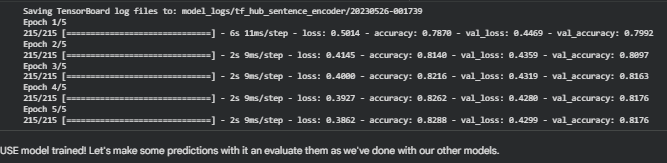

In [ ]:
# Make predictions with USE TF Hub model
model_6_pred_probs = model_6.predict(val_sentences)
model_6_pred_probs[:10]

In [ ]:
# Convert prediction probabilities to labels
model_6_preds = tf.squeeze(tf.round(model_6_pred_probs))
model_6_preds[:10]

In [ ]:
# Calculate model 6 performance metrics
model_6_results = calculate_results(val_labels, model_6_preds)
model_6_results

Baseline accuracy: 79.27, New accuracy: 81.76, Difference: 2.49

Baseline precision: 0.81, New precision: 0.82, Difference: 0.01

Baseline recall: 0.79, New recall: 0.82, Difference: 0.02

Baseline f1: 0.79, New f1: 0.82, Difference: 0.03

---

### Model 7: (+ Pretrained layer + 10% of the training data)

One of the benefits of using transfer learning methods, such as, the pretrained embeddings within the USE is the ability to get great results on a small amount of data (the USE paper even mentions this in the abstract).

To put this to the test, we're going to make a small subset of the training data (10%), train a model and evaluate it.

In [ ]:
### NOTE: Making splits like this will lead to data leakage ###
### (some of the training examples in the validation set) ###

### WRONG WAY TO MAKE SPLITS (train_df_shuffled has already been split) ###

# # Create subsets of 10% of the training data
# train_10_percent = train_df_shuffled[["text", "target"]].sample(frac=0.1, random_state=42)
# train_sentences_10_percent = train_10_percent["text"].to_list()
# train_labels_10_percent = train_10_percent["target"].to_list()
# len(train_sentences_10_percent), len(train_labels_10_percent)

In [ ]:
# One kind of correct way (there are more) to make data subset
# (split the already split train_sentences/train_labels)
train_sentences_90_percent, train_sentences_10_percent, train_labels_90_percent, train_labels_10_percent = train_test_split(np.array(train_sentences),
                                                                                                                            train_labels,
                                                                                                                            test_size=0.1,
                                                                                                                            random_state=42)


In [ ]:
# Check length of 10 percent datasets
print(f"Total training examples: {len(train_sentences)}")
print(f"Length of 10% training examples: {len(train_sentences_10_percent)}")

Total training examples: 6851

Length of 10% training examples: 686

In [ ]:
# Check the number of targets in our subset of data
# (this should be close to the distribution of labels in the original train_labels)
pd.Series(train_labels_10_percent).value_counts()

# Check balance data

In [ ]:
# Clone model_6 but reset weights
model_7 = tf.keras.models.clone_model(model_6)

# Compile model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Get a summary (will be same as model_6)
model_7.summary()

In [ ]:
# Fit the model to 10% of the training data
model_7_history = model_7.fit(x=train_sentences_10_percent,
                              y=train_labels_10_percent,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

In [ ]:
model_7_pred_probs = model_7.predict(val_sentences)
model_7_pred_probs[:10]

In [ ]:
# Convert prediction probabilities to labels
model_7_preds = tf.squeeze(tf.round(model_7_pred_probs))
model_7_preds[:10]

In [ ]:
# Calculate model results
model_7_results = calculate_results(val_labels, model_7_preds)
model_7_results

In [ ]:
compare_baseline_to_new_results(baseline_results, model_7_results)

Baseline accuracy: 79.27, New accuracy: 77.03, Difference: -2.23

Baseline precision: 0.81, New precision: 0.78, Difference: -0.04

Baseline recall: 0.79, New recall: 0.77, Difference: -0.02

Baseline f1: 0.79, New f1: 0.77, Difference: -0.02

---

# Comparing the performance of each of our models

Woah. We've come a long way! From training a baseline to several deep models.

Now it's time to compare our model's results.

But just before we do, it's worthwhile mentioning, this type of practice is a standard deep learning workflow. Training various different models, then comparing them to see which one performed best and continuing to train it if necessary.

The important thing to note is that for all of our modelling experiments we used the same training data (except for `model_7` where we used 10% of the training data).

To visualize our model's performances, let's create a pandas DataFrame we our results dictionaries and then plot it.

In [88]:
# Combine model results into a DataFrame
all_model_results = pd.DataFrame({"baseline": baseline_results,
                                  "simple_dense": model_1_results,
                                  "lstm": model_2_results,
                                  "gru": model_3_results,
                                  "bidirectional": model_4_results,
                                  "conv1d": model_5_results
                                  # "tf_hub_sentence_encoder": model_6_results,
                                  # "tf_hub_10_percent_data": model_7_results
                                  })

all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
baseline,79.265092,0.811139,0.792651,0.786219
simple_dense,77.952756,0.782596,0.779528,0.777005
lstm,77.821522,0.782141,0.778215,0.775320
gru,76.246719,0.764516,0.762467,0.759967
bidirectional,74.015748,0.739621,0.740157,0.739473
conv1d,77.427822,0.777863,0.774278,0.771406


In [89]:
# Reduce the accuracy to same scale as other metrics
all_model_results["accuracy"] = all_model_results["accuracy"]/100

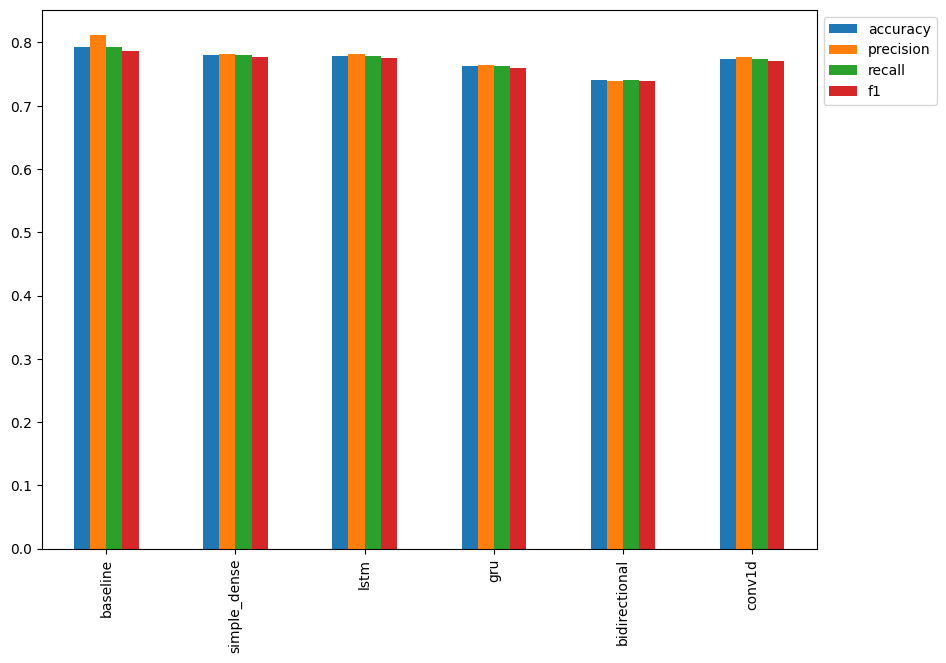

In [90]:
# Plot and compare all of the model results
all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));

Looks like our pretrained USE TensorFlow Hub models have the best performance, even the one with only 10% of the training data seems to outperform the other models. This goes to show the power of transfer learning.

ဒီမှာတော့ error တက်နေလို့ run မရပါ Transfer Learning က။

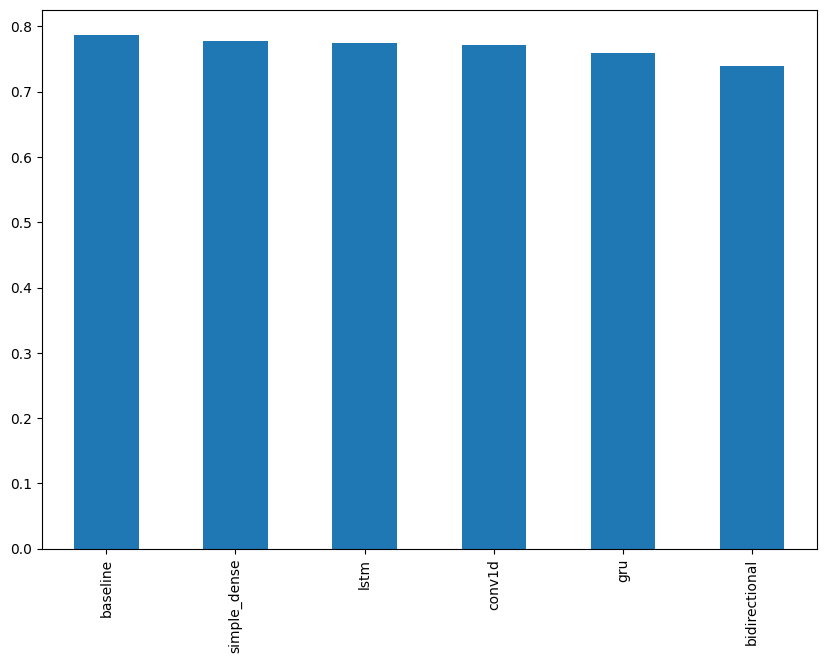

In [91]:
# Sort model results by f1-score
all_model_results.sort_values("f1", ascending=False)["f1"].plot(kind="bar", figsize=(10, 7));

Model များကို ပေါင်းစပ်အသုံးပြုခြင်း (Model Ensembling / Stacking)

Production-level machine learning systems များတွင် prediction တစ်ခုထုတ်ရန် ensemble (model များစွာကို ပေါင်းစပ်အသုံးပြုခြင်း) ကို မကြာခဏ အသုံးပြုကြပါသည်။

Model stacking ၏ အဓိက အယူအဆမှာ မတူညီသော model များက prediction တစ်ခုတည်းကို သဘောတူညီစွာ ခန့်မှန်းပေးလျှင်၊ ထို prediction သည် model တစ်ခုတည်းမှ ထွက်လာသော prediction ထက် ပိုမိုယုံကြည်စိတ်ချရမည် ဟူသော အချက်ဖြစ်သည်။

ဒီနေရာမှာ အရေးကြီးတဲ့ စကားလုံးက "uncorrelated" ဖြစ်ပြီး၊ အဓိပ္ပာယ်ကတော့ မတူညီသော model အမျိုးအစားများ ဟု ဆိုလိုပါသည်။

ဥပမာအားဖြင့် ကျွန်ုပ်တို့၏ project တွင် -

- model_0 → Baseline Model
- model_2 → LSTM Model
- model_6 → USE Model

တို့ကို ပေါင်းစပ်အသုံးပြုနိုင်ပါသည်။

Model သုံးခုစလုံးကို dataset တစ်ခုတည်းပေါ်တွင် train လုပ်ထားသော်လည်း pattern ရှာဖွေပုံများ မတူညီကြပါ။

ဥပမာ -

- Baseline model သည် TF-IDF features များကို အသုံးပြုနိုင်သည်။
- LSTM သည် sequence (word order) ကို သင်ယူသည်။
- USE သည် sentence embedding များကို အသုံးပြုသည်။

ထို့ကြောင့် model များ၏ အားသာချက်များကို ပေါင်းစပ်နိုင်ပါသည်။

---

ဥပမာ

စားသောက်ဆိုင်ရွေးမည့် သူငယ်ချင်းအဖွဲ့တစ်ဖွဲ့ကို စဉ်းစားကြည့်ပါ။

လူအားလုံး အကြိုက်တူနေပါက စားသောက်ဆိုင်တစ်ဆိုင်တည်းကို ရွေးမိနိုင်သည်။

သို့သော် အကြိုက်မတူသော လူများကတောင် စားသောက်ဆိုင်တစ်ဆိုင်တည်းကို ရွေးချယ်ကြလျှင် ထိုဆိုင်သည် အမှန်တကယ် ကောင်းသောဆိုင် ဖြစ်နိုင်ချေ ပိုများပါသည်။

Model ensemble များလည်း ထိုသဘောတရားနှင့် ဆင်တူပါသည်။

---

Classification Problem များတွင် Ensemble လုပ်နည်းများ

1. Averaging

Model တစ်ခုချင်းစီ၏ prediction probability များကို average ယူသည်။

ဥပမာ -

```
| Model    | Probability |
| -------- | ----------- |
| Baseline | 0.80        |
| LSTM     | 0.60        |
| USE      | 0.70        |

```

```
Average:

(0.80+0.60+0.70) / 3 =0.70
```

Final prediction probability = 0.70

---

2. Majority Vote (Mode)

Model တစ်ခုချင်းစီက class label ထုတ်ပေးသည်။

ဥပမာ -
```
Baseline = 1
LSTM     = 0
USE      = 1
```

```
ရလဒ်:

[1, 0, 1]
```
1 က နှစ်ကြိမ်ပါဝင်သောကြောင့်
```
Final Prediction = 1
```


---

3. Model Stacking

Model တစ်ခုချင်းစီ၏ output များကို model အသစ်တစ်ခု၏ input အဖြစ် ပြန်ထည့်သည်။

ဥပမာ -

```
Baseline Output ──┐
                  │
LSTM Output ──────┼──► Meta Model
                  │
USE Output ───────┘
```

Meta Model က final prediction ကို ထုတ်ပေးသည်။

Stacking သည် ensemble နည်းများထဲတွင် အဆင့်မြင့်ဆုံးနည်းလမ်းတစ်ခု ဖြစ်သည်။

ဒီ Project မှာ ဘာလုပ်မလဲ?

သင်ခန်းစာတွင်
```
model_0 (Baseline)
model_2 (LSTM)
model_6 (USE)
```
တို့ကို ensemble လုပ်မည် ဖြစ်သည်။

သို့သော် သင့် environment တွင် USE မရသေးသောကြောင့်

```
model_0
model_2
DistilBERT (သို့) SentenceTransformer Model
```

တို့ကို ensemble လုပ်လျှင်လည်း အယူအဆတူညီပြီး ပိုမိုခေတ်မီသော approach ဖြစ်ပါသည်။

နောက်အဆင့်တွင် Averaging Ensemble ကို code ဖြင့် ဘယ်လို implement လုပ်ရမလဲဆိုတာ ဆက်သွားနိုင်ပါတယ်။

---

# Saving and loading a trained model

Although training time didn't take very long, it's good practice to save your trained models to avoid having to retrain them.

Saving your models also enables you to export them for use elsewhere outside of your notebooks, such as in a web application.

There are two main ways of [saving a model in TensorFlow](https://www.tensorflow.org/tutorials/keras/save_and_load#save_the_entire_model):
1. The `HDF5` format.
2. The `SavedModel` format (default).

Let's take a look at both.

In [ ]:
model_6.save("model_6.h5")

In [ ]:
# Load model with custom Hub Layer (required with HDF5 format)
loaded_model_6 = tf.keras.models.load_model("model_6.h5",
                                            custom_objects={"KerasLayer": hub.KerasLayer})

In [ ]:
# How does our loaded model perform?
loaded_model_6.evaluate(val_sentences, val_labels)

Calling the `save()` method on our target model and passing it a filepath allows us to save our model in the `SavedModel` format.

In [ ]:
# Save TF Hub Sentence Encoder model to SavedModel format (default)
model_6.save("model_6_SavedModel_format")

In [ ]:
# Load TF Hub Sentence Encoder SavedModel
loaded_model_6_SavedModel = tf.keras.models.load_model("model_6_SavedModel_format")

In [ ]:
# Evaluate loaded SavedModel format
loaded_model_6_SavedModel.evaluate(val_sentences, val_labels)

As you can see saving and loading our model with either format results in the same performance.

> 🤔 **Question:** Should you use the `SavedModel` format or `HDF5` format?

For most use cases, the `SavedModel` format will suffice. However, this is a TensorFlow specific standard. If you need a more general-purpose data standard, `HDF5` might be better. For more, check out the [TensorFlow documentation on saving and loading models](https://www.tensorflow.org/tutorials/keras/save_and_load).

## Finding the most wrong examples

We mentioned before that if many of our modelling experiments are returning similar results, despite using different kinds of models, it's a good idea to return to the data and inspect why this might be.

One of the best ways to inspect your data is to sort your model's predictions and find the samples it got *most* wrong, meaning, what predictions had a high prediction probability but turned out to be wrong.

Once again, visualization is your friend. Visualize, visualize, visualize.

To make things visual, let's take our best performing model's prediction probabilities and classes along with the validation samples (text and ground truth labels) and combine them in a pandas DataFrame.

* If our best model still isn't perfect, what examples is it getting wrong?
* Which ones are the *most* wrong?
* Are there some labels which are wrong? E.g. the model gets it right but the ground truth label doesn't reflect this

In [ ]:
# Create dataframe with validation sentences and best performing model predictions
val_df = pd.DataFrame({"text": val_sentences,
                       "target": val_labels,
                       "pred": model_6_preds,
                       "pred_prob": tf.squeeze(model_6_pred_probs)})
val_df.head()

In [ ]:
# Find the wrong predictions and sort by prediction probabilities
most_wrong = val_df[val_df["target"] != val_df["pred"]].sort_values("pred_prob", ascending=False)
most_wrong[:10]

Finally, we can write some code to visualize the sample text, truth label, prediction class and prediction probability. Because we've sorted our samples by prediction probability, viewing samples from the head of our `most_wrong` DataFrame will show us false positives.

A reminder:
* `0` = Not a real diaster Tweet
* `1` = Real diaster Tweet

In [ ]:
# Check the false positives (model predicted 1 when should've been 0)
for row in most_wrong[:10].itertuples(): # loop through the top 10 rows (change the index to view different rows)
  _, text, target, pred, prob = row
  print(f"Target: {target}, Pred: {int(pred)}, Prob: {prob}")
  print(f"Text:\n{text}\n")
  print("----\n")

We can view the bottom end of our `most_wrong` DataFrame to inspect false negatives (model predicts 0, not a real diaster Tweet, when it should've predicted 1, real diaster Tweet).

In [ ]:
# Check the most wrong false negatives (model predicted 0 when should've predict 1)
for row in most_wrong[-10:].itertuples():
  _, text, target, pred, prob = row
  print(f"Target: {target}, Pred: {int(pred)}, Prob: {prob}")
  print(f"Text:\n{text}\n")
  print("----\n")

Do you notice anything interesting about the most wrong samples?

Are the ground truth labels correct? What do you think would happen if we went back and corrected the labels which aren't?

# Speed/Score Tradeoff (မြန်နှုန်း နှင့် Accuracy)

ယခု နောက်ဆုံးစမ်းသပ်မည့် အရာများထဲမှ တစ်ခုမှာ အကောင်းဆုံး model နှင့် baseline model တို့အကြား speed/score tradeoff ကို လေ့လာခြင်း ဖြစ်ပါသည်။

ဘာကြောင့် အရေးကြီးတာလဲ?

Model တစ်ခုကို စမ်းသပ်မှုများပြုလုပ်ပြီး accuracy အမြင့်ဆုံးရသော model ကို ရွေးချယ်ချင်စိတ် ဖြစ်နိုင်ပါသည်။

သို့သော် ထို model သည် production environment (လက်တွေ့အသုံးပြုမည့် system) တွင် အမှန်တကယ် သင့်တော်မည်ဟု မဆိုလိုပါ။

---

ဥပမာ: Twitter ကုမ္ပဏီတစ်ခုကို စဉ်းစားကြည့်ပါ။

တစ်နာရီလျှင် Tweet 1 သန်း (ဥပမာအတွက်သာ) ဝင်လာသည်ဟု ယူဆပါစို့။

သင်သည် disaster detection system တစ်ခုကို တည်ဆောက်နေပြီး disaster ဖြစ်ပွားမှုများကို real-time နီးပါး သိရှိနိုင်ရန် ကြိုးစားနေသည်။

သို့သော် compute resources များသည် အခမဲ့မဟုတ်ပါ။

ထို့ကြောင့် project အတွက် server (machine) တစ်လုံးသာ အသုံးပြုနိုင်သည်။


```
Model နှစ်ခု ရှိသည်ဟု ယူဆပါစို့

Model A
- Accuracy = 80%
- Speed = 10,000 predictions/second

Model B
- Accuracy = 85%
- Speed = 100 predictions/second

ဘယ် Model ကို ရွေးမလဲ?

Model B က accuracy ပိုကောင်းသည်။
```

သို့သော်

```
80% → 85%
```

အတွက်

```
10,000 predictions/sec
↓
100 predictions/sec
```

အထိ စွမ်းဆောင်ရည် ကျဆင်းသွားသည်။

ထိုအချိန်တွင် မေးခွန်းက

- Accuracy 5% တိုးလာခြင်းသည် Processing Capacity အများကြီး ဆုံးရှုံးရခြင်းနှင့် တန်ဖိုးရှိပါသလား?

---

လက်တွေ့အသုံးပြုနိုင်သော နည်းလမ်း

ဥပမာ -

Tweet အများစုကို မြန်ဆန်သော Model A သို့ ပို့မည်။
Model A က confidence နည်းသော Tweet များကိုသာ Model B သို့ ထပ်ပို့မည်။

```
Incoming Tweets
       │
       ▼
   Fast Model
       │
 ┌─────┴─────┐
 │ Confident │ ──► Final Prediction
 │           │
 └───────────┘

       │ Uncertain
       ▼
Slow Accurate Model
       │
       ▼
  Final Prediction
```

ဒီလို architecture များကို production systems တွင် မကြာခဏ အသုံးပြုကြသည်။

အဓိက သင်ခန်းစာ

စမ်းသပ်မှုများအတွင်း accuracy အကောင်းဆုံး ရသော model သည်

Production တွင် အသုံးပြုမည့် model ဖြစ်မည်ဟု မသေချာပါ။

Production အတွက် ရွေးချယ်ရာတွင်

- Accuracy
- Inference Speed
- Memory Usage
- Compute Cost
- Scalability

တို့ကို အတူတကွ စဉ်းစားရပါမည်။

ဒီသင်ခန်းစာမှာ ဘာလုပ်မလဲ?

Model တစ်ခုသည် prediction လုပ်ရန် အချိန်ဘယ်လောက် ကြာသလဲဆိုတာ တိုင်းတာရန် function တစ်ခု ရေးပါမည်။

ဥပမာ -

```
time_taken = predict(model, samples)
```

ကဲ့သို့ model တစ်ခုကို sample များပေးပြီး

- Prediction time
- Samples per second
- Accuracy

တို့ကို တွက်ချက်ကာ

```
"ဘယ် model က accuracy ကောင်းပြီး မြန်လည်း မြန်သလဲ?"
```

ဆိုတာကို နှိုင်းယှဉ်သွားမည် ဖြစ်ပါသည်။


In [ ]:
# Calculate the time of predictions
import time
def pred_timer(model, samples):
  """
  Times how long a model takes to make predictions on samples.

  Args:
  ----
  model = a trained model
  sample = a list of samples

  Returns:
  ----
  total_time = total elapsed time for model to make predictions on samples
  time_per_pred = time in seconds per single sample
  """
  start_time = time.perf_counter() # get start time
  model.predict(samples) # make predictions
  end_time = time.perf_counter() # get finish time
  total_time = end_time-start_time # calculate how long predictions took to make
  time_per_pred = total_time/len(val_sentences) # find prediction time per sample
  return total_time, time_per_pred

In [ ]:
# Calculate TF Hub Sentence Encoder prediction times
model_6_total_pred_time, model_6_time_per_pred = pred_timer(model_6, val_sentences)
model_6_total_pred_time, model_6_time_per_pred

In [ ]:
# Calculate Naive Bayes prediction times
baseline_total_pred_time, baseline_time_per_pred = pred_timer(model_0, val_sentences)
baseline_total_pred_time, baseline_time_per_pred

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(baseline_time_per_pred, baseline_results["f1"], label="baseline")
plt.scatter(model_6_time_per_pred, model_6_results["f1"], label="tf_hub_sentence_encoder")
plt.legend()
plt.title("F1-score versus time per prediction")
plt.xlabel("Time per prediction")
plt.ylabel("F1-Score");

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/08-ideal-performance-speed-of-pred-tradeoff-highlighted.png)
*Ideal position for speed and performance tradeoff model (fast predictions with great results).*

Of course, the ideal position for each of these dots is to be in the top left of the plot (low time per prediction, high F1-score).

In our case, there's a clear tradeoff for time per prediction and performance. Our best performing model takes an order of magnitude longer per prediction but only results in a few F1-score point increase.

This kind of tradeoff is something you'll need to keep in mind when incorporating machine learning models into your own applications.